In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from datetime import timedelta
import matplotlib.pyplot as plt

np.random.seed(42)
n=1000
df = pd.DataFrame({
    'order_id': [f'O{i}' for i in range(1, n+1)],
    'customer_id': np.random.choice([f'C{i}' for i in range(1, 201)], n),
    'order_date': pd.to_datetime('2021-01-01') + pd.to_timedelta(np.random.randint(0, 365, n), unit='D'),
    'ship_date': pd.to_datetime('2021-01-01') + pd.to_timedelta(np.random.randint(1, 370, n), unit='D'),
    'product_id': np.random.choice([f'P{i}' for i in range(1, 501)], n),
    'category': np.random.choice(['Electronics','Clothing','Furniture','Toys','Books'], n),
    'price': np.random.randint(200, 50000, n),
    'quantity': np.random.randint(1, 5, n),
    'payment_type': np.random.choice(['Credit Card','Debit Card','UPI','COD'], n),
    'city': np.random.choice([f'City_{i}' for i in range(1, 51)], n),
    'review_text': np.random.choice(['Great product','Bad service','Loved it','Not good','Excellent','Okay experience'], n)
})

In [2]:
df.head()

,order_id,customer_id,order_date,ship_date,product_id,category,price,quantity,payment_type,city,review_text
0,O1,C103,2021-08-24,2021-09-04,P495,Books,33922,3,COD,City_30,Great product
1,O2,C180,2021-03-24,2021-05-06,P424,Books,10825,2,Credit Card,City_40,Loved it
2,O3,C93,2021-02-11,2021-09-26,P294,Books,1829,4,Debit Card,City_7,Excellent
3,O4,C15,2021-04-11,2021-05-12,P444,Furniture,11173,3,Credit Card,City_32,Bad service
4,O5,C107,2021-01-06,2021-08-26,P59,Books,7059,1,COD,City_48,Excellent


In [4]:
df['returned']=((df['price']<5000).astype(int)+(df['category']=='Clothing').astype(int))>0
df['returned']=df['returned'].astype(int)
df.head()

,order_id,customer_id,order_date,ship_date,product_id,category,price,quantity,payment_type,city,review_text,returned
0,O1,C103,2021-08-24,2021-09-04,P495,Books,33922,3,COD,City_30,Great product,0
1,O2,C180,2021-03-24,2021-05-06,P424,Books,10825,2,Credit Card,City_40,Loved it,0
2,O3,C93,2021-02-11,2021-09-26,P294,Books,1829,4,Debit Card,City_7,Excellent,1
3,O4,C15,2021-04-11,2021-05-12,P444,Furniture,11173,3,Credit Card,City_32,Bad service,0
4,O5,C107,2021-01-06,2021-08-26,P59,Books,7059,1,COD,City_48,Excellent,0


In [5]:
df['order_value']=df['price']*df['quantity']
df['order_value'].astype(int)

0      101766
1       21650
2        7316
3       33519
4        7059
        ...  
995    137488
996     23524
997     20874
998      4182
999    136449
Name: order_value, Length: 1000, dtype: int64

In [6]:
df.head()

,order_id,customer_id,order_date,ship_date,product_id,category,price,quantity,payment_type,city,review_text,returned,order_value
0,O1,C103,2021-08-24,2021-09-04,P495,Books,33922,3,COD,City_30,Great product,0,101766
1,O2,C180,2021-03-24,2021-05-06,P424,Books,10825,2,Credit Card,City_40,Loved it,0,21650
2,O3,C93,2021-02-11,2021-09-26,P294,Books,1829,4,Debit Card,City_7,Excellent,1,7316
3,O4,C15,2021-04-11,2021-05-12,P444,Furniture,11173,3,Credit Card,City_32,Bad service,0,33519
4,O5,C107,2021-01-06,2021-08-26,P59,Books,7059,1,COD,City_48,Excellent,0,7059


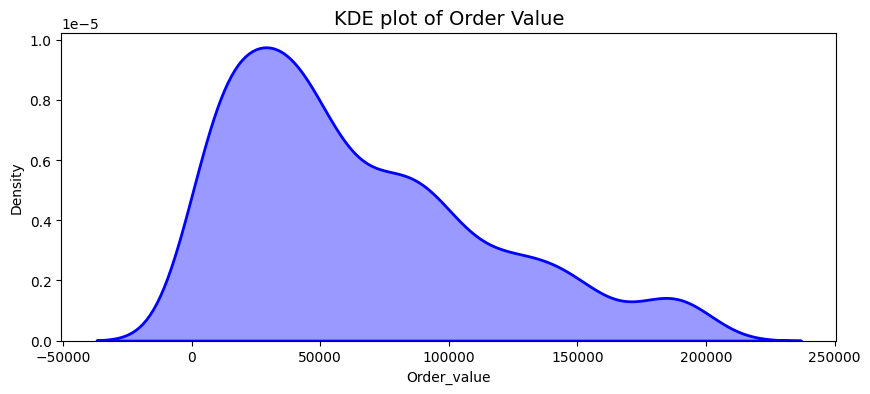

In [8]:
plt.figure(figsize=(10,4))
sns.kdeplot(df['order_value'],fill=True,color="blue",alpha=0.4,linewidth=2)
plt.title("KDE plot of Order Value",fontsize=14)
plt.xlabel('Order_value')
plt.ylabel("Density")
plt.show()

In [9]:
# transformation

df['log_order_value']=np.log(df['order_value'])

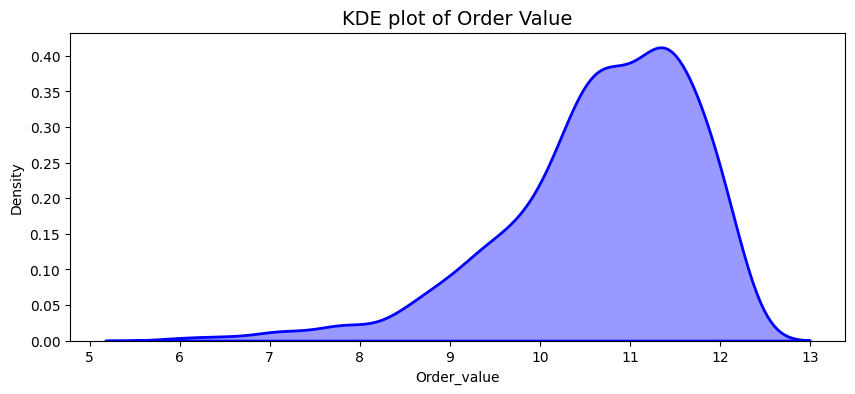

In [10]:
plt.figure(figsize=(10,4))
sns.kdeplot(df['log_order_value'],fill=True,color="blue",alpha=0.4,linewidth=2)
plt.title("KDE plot of Order Value",fontsize=14)
plt.xlabel('Order_value')
plt.ylabel("Density")
plt.show()

In [11]:
df['log_order_value']=np.sqrt(df['order_value'])

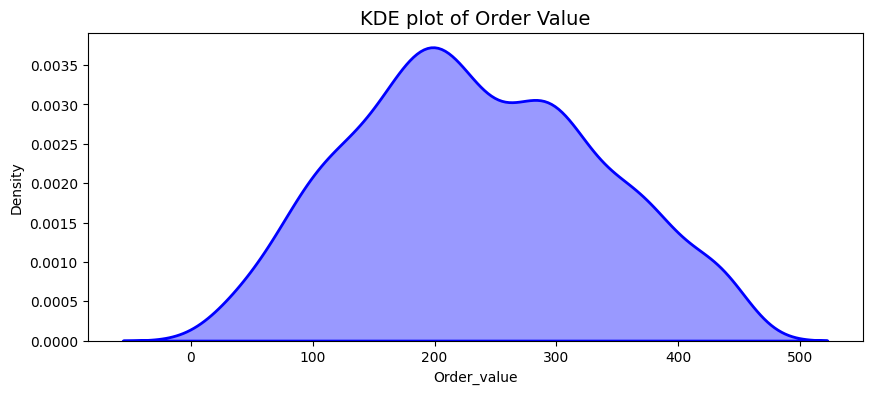

In [12]:
plt.figure(figsize=(10,4))
sns.kdeplot(df['log_order_value'],fill=True,color="blue",alpha=0.4,linewidth=2)
plt.title("KDE plot of Order Value",fontsize=14)
plt.xlabel('Order_value')
plt.ylabel("Density")
plt.show()

Date / Time

In [30]:

df['oder_dow']=df['order_date'].dt.dayofweek
df['oder_month']=df['order_date'].dt.month
df['ship_delay']=(df['ship_date']-df['order_date']).dt.days

In [31]:
df.head()

,order_id,customer_id,order_date,ship_date,product_id,category,price,quantity,payment_type,city,review_text,returned,order_value,log_order_value,oder_dow,oder_month,ship_delay
0,O1,C103,2021-08-24,2021-09-04,P495,Books,33922,3,COD,City_30,Great product,0,101766,319.007837,1,8,11
1,O2,C180,2021-03-24,2021-05-06,P424,Books,10825,2,Credit Card,City_40,Loved it,0,21650,147.139390,2,3,43
2,O3,C93,2021-02-11,2021-09-26,P294,Books,1829,4,Debit Card,City_7,Excellent,1,7316,85.533619,3,2,227
3,O4,C15,2021-04-11,2021-05-12,P444,Furniture,11173,3,Credit Card,City_32,Bad service,0,33519,183.081949,6,4,31
4,O5,C107,2021-01-06,2021-08-26,P59,Books,7059,1,COD,City_48,Excellent,0,7059,84.017855,2,1,232


In [ ]:
df['order_month_sin']=np.sin(2*np.pi*df['oder_month']/12)
df['order_month_cos']=np.cos(2*np.pi*df['oder_month']/12)
df.head()


,order_id,customer_id,order_date,ship_date,product_id,category,price,quantity,payment_type,city,review_text,returned,order_value,log_order_value,oder_dow,oder_month,ship_delay,order_month_sin,order_month_cos
0,O1,C103,2021-08-24,2021-09-04,P495,Books,33922,3,COD,City_30,Great product,0,101766,319.007837,1,8,11,-0.866025,-5.000000e-01
1,O2,C180,2021-03-24,2021-05-06,P424,Books,10825,2,Credit Card,City_40,Loved it,0,21650,147.139390,2,3,43,1.000000,6.123234e-17
2,O3,C93,2021-02-11,2021-09-26,P294,Books,1829,4,Debit Card,City_7,Excellent,1,7316,85.533619,3,2,227,0.866025,5.000000e-01
3,O4,C15,2021-04-11,2021-05-12,P444,Furniture,11173,3,Credit Card,City_32,Bad service,0,33519,183.081949,6,4,31,0.866025,-5.000000e-01
4,O5,C107,2021-01-06,2021-08-26,P59,Books,7059,1,COD,City_48,Excellent,0,7059,84.017855,2,1,232,0.500000,8.660254e-01


In [39]:
cus_agre=df.groupby('customer_id').agg({
    'order_value':['mean','sum','count'],
    'returned':'mean'
}).reset_index()
cus_agre.columns

MultiIndex([('customer_id',      ''),
            ('order_value',  'mean'),
            ('order_value',   'sum'),
            ('order_value', 'count'),
            (   'returned',  'mean')],
           )

In [40]:
cus_agre.columns = ['customer_id','cust_avg_order_val','cust_total_spent','cust_order_count','cust_return_rate']
cus_agre.head()

,customer_id,cust_avg_order_val,cust_total_spent,cust_order_count,cust_return_rate
0,C1,83224.25,665794,8,0.125000
1,C10,60626.00,121252,2,0.500000
2,C100,100058.25,400233,4,0.500000
3,C101,52584.00,368088,7,0.285714
4,C102,34390.00,68780,2,0.000000


In [42]:
df=df.merge(cus_agre,on='customer_id',how='left')
df.head()

,order_id,customer_id,order_date,ship_date,product_id,category,price,quantity,payment_type,city,...,order_month_sin,order_month_cos,cust_avg_order_val_x,cust_total_spent_x,cust_order_count_x,cust_return_rate_x,cust_avg_order_val_y,cust_total_spent_y,cust_order_count_y,cust_return_rate_y
0,O1,C103,2021-08-24,2021-09-04,P495,Books,33922,3,COD,City_30,...,-0.866025,-5.000000e-01,73930.833333,443585,6,0.333333,73930.833333,443585,6,0.333333
1,O2,C180,2021-03-24,2021-05-06,P424,Books,10825,2,Credit Card,City_40,...,1.000000,6.123234e-17,71166.833333,427001,6,0.166667,71166.833333,427001,6,0.166667
2,O3,C93,2021-02-11,2021-09-26,P294,Books,1829,4,Debit Card,City_7,...,0.866025,5.000000e-01,38970.571429,272794,7,0.285714,38970.571429,272794,7,0.285714
3,O4,C15,2021-04-11,2021-05-12,P444,Furniture,11173,3,Credit Card,City_32,...,0.866025,-5.000000e-01,35871.285714,251099,7,0.428571,35871.285714,251099,7,0.428571
4,O5,C107,2021-01-06,2021-08-26,P59,Books,7059,1,COD,City_48,...,0.500000,8.660254e-01,76688.333333,230065,3,0.000000,76688.333333,230065,3,0.000000


Category Features

In [43]:
cat_agg=df.groupby('category').agg({
    'order_value':'mean',
    'returned':'mean',
    'order_id':'count'
}).reset_index()
cat_agg

,category,order_value,returned,order_id
0,Books,67780.400000,0.075000,200
1,Clothing,62038.841270,1.000000,189
2,Electronics,62401.369863,0.082192,219
3,Furniture,66862.686567,0.124378,201
4,Toys,66266.099476,0.068063,191


In [45]:
cat_agg.columns=['category','cat_avg_order_val','cat_return_rate','cat_order_count']
cat_agg.head()

,category,cat_avg_order_val,cat_return_rate,cat_order_count
0,Books,67780.400000,0.075000,200
1,Clothing,62038.841270,1.000000,189
2,Electronics,62401.369863,0.082192,219
3,Furniture,66862.686567,0.124378,201
4,Toys,66266.099476,0.068063,191
